<a href="https://colab.research.google.com/github/chaitragopalappa/MIE590-690D/blob/main/4_PINN/2b_NeuralODE_SIR_withPhysics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  PROBLEM SETTING: Neural ODEs with known physics and missing coefficients
##  (EPIDEMIC EXAMPLE -S,I,R model)
$$[y_1, y_2, y_3]=[S,I,R]$$
  $$\frac{dS}{dt} = (-\beta  S  I)$$
  $$ \frac{dI}{dt} = (\beta  S  I - \gamma  I)$$
  $$ \frac{dR}{dt} = (\gamma  I)$$

Suppose
- We do not know beta, but known functional form of x1 and x2
- We do not know functional form of x3
We incoporate what we know and use NN to predict what we do not know.
Compare results with code 2a where we assumed no prior knowledge of the physics. What you will expect to see
- 2a will need more effort in hyperparamter tuning, but may converge in the simplistic example.
- 2b will converge with not much effort, in this simplistic example.


In [ ]:
!pip install torchdiffeq

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
#from torchdiffeq import odeint_adjoint as odeint  # note use of adjoint v regular backprop
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# Define the Neural Network representing the ODE vector field (ds/dt, di/dt, dr/dt)
# maps [t,x1,x2,x3]--> dx1/dt,dx2/dt, dx3/dt
class ODEFunc(nn.Module):
    def __init__(self):
        super(ODEFunc, self).__init__()

        #Set beta as learnable parameter
        self.beta = nn.Parameter(torch.tensor(0.2, dtype=torch.float32))
        # Setup network to learn dx3/dt; take in 3 states (x1,x2,x3) and return 1 orut corresponding to dx3/dt
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, t, x):
        #dy_dt = self.net(x)
        #return dy_dt
        x_in = x.unsqueeze(0) if x.dim() == 1 else x
        S_p, I_p, R_p = x_in[:, 0:1], x_in[:, 1:2], x_in[:, 2:3]
        dx1_dt = (-self.beta * S_p * I_p)
        dx2_dt = (self.beta * S_p * I_p - gamma * I_p)
        dx3_dt = self.net(x_in)
        dx_dt = torch.cat([dx1_dt, dx2_dt, dx3_dt], dim=1)
        return dx_dt.squeeze(0) if x.dim() == 1 else dx_dt

# DATA PREPARATION
Generating y observations. Replace this with actual observations.

In [ ]:

gamma = 0.1 # In this example, we assume we know these parameters- which are the coefficients in the ODEs.

# Initial populations: S=0.99, I=0.01, E=0.00
initial_state = torch.tensor([0.99, 0.01, 0.00], dtype=torch.float32)
t_data = torch.linspace(0., 40., 160)  # 160 time points from t=0 to t=40

def true_sir_dynamics(t, x):
    beta = 0.3
    S, I, R = x[0], x[1], x[2]
    return torch.stack([-beta*S*I, beta*S*I - gamma*I, gamma*I])
with torch.no_grad():
    true_x = odeint(true_sir_dynamics, initial_state, t_data)
batch_time_steps = 15  # Slicing window size for stabilization
total_steps = t_data.size(0)

# TRAIN

In [ ]:
# Initialize Model and Optimizer
func = ODEFunc()
optimizer = optim.Adam(func.parameters(), lr=0.005)
loss_fn = nn.MSELoss() #(Mean Squared Error) Loss
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100, factor=0.5)

# Training Loop
epochs = 500
for epoch in range(epochs):
      optimizer.zero_grad()


      # Randomly pick a starting index that allows for a full continuous window
      max_start_idx = total_steps - batch_time_steps
      start_idx = torch.randint(0, max_start_idx, (1,)).item()

      t_batch = t_data[start_idx : start_idx + batch_time_steps]
      x_batch = true_x[start_idx : start_idx + batch_time_steps]

      # CRITICAL: The initial state must match the beginning of this specific time window
      batch_initial_state = x_batch[0]
      pred_x = odeint(func, batch_initial_state, t_batch, method='rk4')
      # Compute loss
      loss = loss_fn(pred_x, x_batch)

      loss.backward()
      optimizer.step()
      scheduler.step(loss)

      if epoch % 100 == 0:
          print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

Epoch 000 | Loss: 0.011933
Epoch 100 | Loss: 0.000001
Epoch 200 | Loss: 0.000000
Epoch 300 | Loss: 0.000001
Epoch 400 | Loss: 0.000000


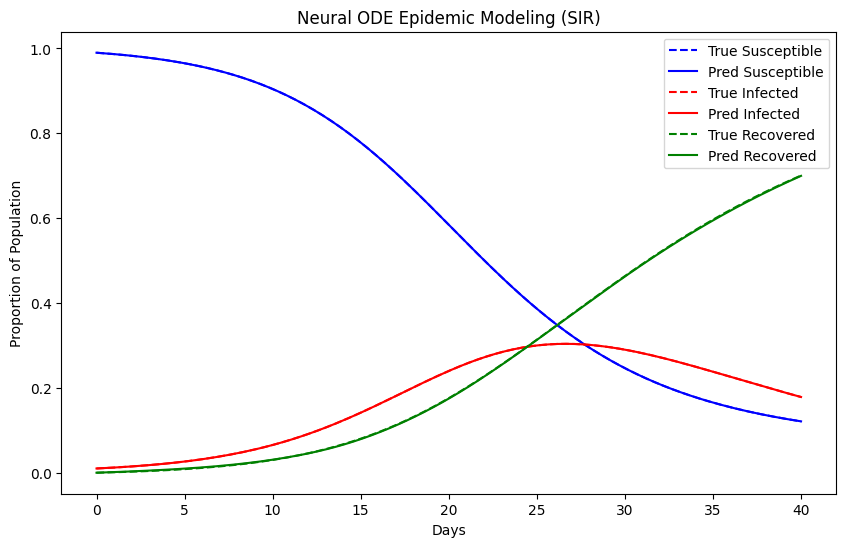

In [ ]:
# Plot Results
#
with torch.no_grad():
    # Evaluate across the entire timeline starting back at absolute t=0
    final_predictions = odeint(func, initial_state, t_data)
plt.figure(figsize=(10, 6))
labels = ['Susceptible', 'Infected', 'Recovered']
colors = ['blue', 'red', 'green']
for i in range(3):
    plt.plot(t_data.numpy(), true_y[:, i].numpy(), label=f'True {labels[i]}', color=colors[i], linestyle='--')
    plt.plot(t_data.numpy(), final_predictions[:, i].numpy(), label=f'Pred {labels[i]}', color=colors[i])

plt.title('Neural ODE Epidemic Modeling (SIR)')
plt.xlabel('Days')
plt.ylabel('Proportion of Population')
plt.legend()
plt.show()